In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


In [2]:
def create_dl(file_starts=None, shuffle_selection=False):
    if file_starts is None:
        file_starts = ["tr_"]
    logvar = []
    mu = []
    labels = []
    for arg in file_starts:
        logvar.extend(torch.load(arg + "logvar.pt"))
        mu.extend(torch.load(arg + "mu.pt"))
        labels.extend(torch.load(arg + "labels.pt"))
    
    features = []
    for i in range(len(logvar)):
        l = logvar[i][0].detach().numpy()
        m = mu[i][0].detach().numpy()
        features.append(np.concatenate((l, m), axis=0))
    
    features = np.array(features)
    
    print(features.shape)
    
    unique_labels = sorted(set(labels))
    label_to_idx   = {lbl:idx for idx,lbl in enumerate(unique_labels)}
    labels_idx = [label_to_idx[l] for l in labels]
    
    new_X = features.astype(np.float32)                         # (4801, 400)
    new_y = np.array(labels_idx)                           # (4801,)
    
    batch_size = 64
    
    return unique_labels, label_to_idx, labels_idx, DataLoader(TensorDataset(torch.from_numpy(new_X),
                                        torch.from_numpy(new_y)),
                          batch_size=batch_size, shuffle=shuffle_selection)

In [3]:
unique_labels, label_to_idx, labels_idx, train_dl = create_dl(["tr_"])
_, _, _, valid_dl = create_dl(["val_"])
_, _, _, test_dl = create_dl(["test_"])

(48195, 256)
(16058, 256)
(16071, 256)


In [4]:
class MLP(nn.Module):
    def __init__(self, d_in=256, d_out=53):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, d_out)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Using device: cpu


Epoch 1000 • train loss 0.4870 • valid acc 76.93%


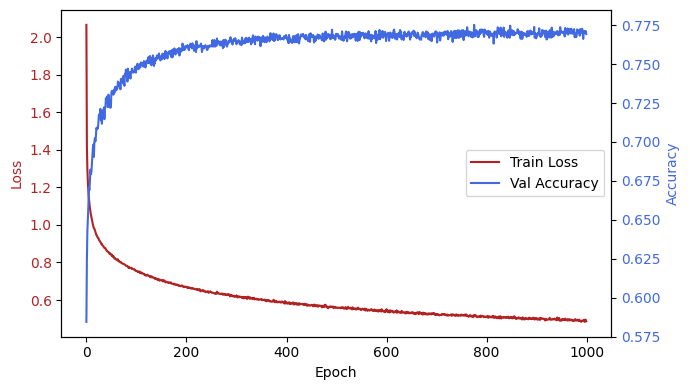

In [5]:
num_epochs = 1000
train_losses = []
val_accuracys = []

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    # validation
    model.eval()
    with torch.no_grad():
        val_logits = torch.cat([model(xb.to(device)) for xb, _ in valid_dl])
        val_targets = torch.cat([yb for _, yb in valid_dl]).to(device)
        val_preds = val_logits.argmax(1)
        val_acc = (val_preds == val_targets).float().mean().item()
    
    train_losses.append(epoch_loss/len(train_dl.dataset))
    val_accuracys.append(val_acc)
    
    if epoch % 10 == 0:
        clear_output()
        print(f"Epoch {epoch:02d} • train loss {epoch_loss/len(train_dl.dataset):.4f} "
          f"• valid acc {val_acc*100:5.2f}%")
        
        fig, ax1 = plt.subplots(figsize=(7,4))
        
        ax1.plot(train_losses, color='firebrick', label='Train Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color='firebrick')
        ax1.tick_params(axis='y', labelcolor='firebrick')
        
        ax2 = ax1.twinx()            # share the same x-axis
        ax2.plot(val_accuracys, color='royalblue', label='Val Accuracy')
        ax2.set_ylabel('Accuracy', color='royalblue')
        ax2.tick_params(axis='y', labelcolor='royalblue')
        
        lines  = ax1.get_lines() + ax2.get_lines()
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='center right')
        
        fig.tight_layout()
        plt.show()

In [6]:
torch.save(model, "MLPClassifierFull.pt")
# model =  torch.load('MLPClassifier.pt', weights_only=False)

In [7]:
model.eval()
with torch.no_grad():
    test_logits = torch.cat([model(xb.to(device)) for xb, _ in test_dl])
    test_targets = torch.cat([yb for _, yb in test_dl]).to(device)
    test_preds = test_logits.argmax(1)


test_acc = accuracy_score(test_targets.cpu(), test_preds.cpu())
print(f"\nTEST accuracy: {test_acc*100:5.2f}%")

sil_count = 0
sil_right = 0
other_count = 0
other_right = 0
true_sil = 0

sil_index = label_to_idx['sil']

y_true, y_pred = test_targets.cpu(), test_preds.cpu()

for i in range(len(y_pred)):
    if y_pred[i] == sil_index:
        sil_count += 1
        if y_pred[i] == y_true[i]:
            sil_right += 1
    else:
        other_count += 1
        if y_pred[i] == y_true[i]:
            other_right += 1
        elif y_true[i] == sil_index:
            true_sil += 1

print(f"Total 'sil' appearances: {sil_right + true_sil}/{sil_count + other_count} total words ({(sil_right + true_sil) / (sil_count + other_count) * 100:.1f}%)")
print(f"Guesses correct when guessing 'sil': {sil_right}/{sil_count} ({(sil_right) / (sil_count) * 100:.1f}%)")
print(f"Guesses correct when guessing other words: {other_right}/{other_count} ({(other_right) / (other_count) * 100:.1f}%)")
print(f"Times we guessed other words, when the true word was 'sil': {true_sil}/{other_count} ({(true_sil) / (other_count) * 100:.1f}%)")



TEST accuracy: 77.30%
Total 'sil' appearances: 3995/16071 total words (24.9%)
Guesses correct when guessing 'sil': 3945/4198 (94.0%)
Guesses correct when guessing other words: 8478/11873 (71.4%)
Times we guessed other words, when the true word was 'sil': 50/11873 (0.4%)


In [10]:
_, _, _, outside_test_dl = create_dl(["outside_test_"])

(16125, 256)


In [11]:
model.eval()
with torch.no_grad():
    test_logits = torch.cat([model(xb.to(device)) for xb, _ in outside_test_dl])
    test_targets = torch.cat([yb for _, yb in outside_test_dl]).to(device)
    test_preds = test_logits.argmax(1)


test_acc = accuracy_score(test_targets.cpu(), test_preds.cpu())
print(f"\nTEST accuracy: {test_acc*100:5.2f}%")

sil_count = 0
sil_right = 0
other_count = 0
other_right = 0
true_sil = 0

sil_index = label_to_idx['sil']

y_true, y_pred = test_targets.cpu(), test_preds.cpu()

for i in range(len(y_pred)):
    if y_pred[i] == sil_index:
        sil_count += 1
        if y_pred[i] == y_true[i]:
            sil_right += 1
    else:
        other_count += 1
        if y_pred[i] == y_true[i]:
            other_right += 1
        elif y_true[i] == sil_index:
            true_sil += 1

print(f"Total 'sil' appearances: {sil_right + true_sil}/{sil_count + other_count} total words ({(sil_right + true_sil) / (sil_count + other_count) * 100:.1f}%)")
print(f"Guesses correct when guessing 'sil': {sil_right}/{sil_count} ({(sil_right) / (sil_count) * 100:.1f}%)")
print(f"Guesses correct when guessing other words: {other_right}/{other_count} ({(other_right) / (other_count) * 100:.1f}%)")
print(f"Times we guessed other words, when the true word was 'sil': {true_sil}/{other_count} ({(true_sil) / (other_count) * 100:.1f}%)")


TEST accuracy: 52.37%
Total 'sil' appearances: 3996/16125 total words (24.8%)
Guesses correct when guessing 'sil': 3824/5400 (70.8%)
Guesses correct when guessing other words: 4620/10725 (43.1%)
Times we guessed other words, when the true word was 'sil': 172/10725 (1.6%)
